# Segundo Proyecto: inestabilidad de Taylor-Rayleight

Santiago Andrés Acosta Díaz

# Marco teórico

## Referencias

[1] Ye Zhou, et al - "Rayleigh–Taylor and Richtmyer–Meshkov instabilities: A journey through scales", secciones 2, 11 y 12

[2] A. Mignone, et al - THE PLUTO CODE FOR ADAPTIVE MESH COMPUTATIONS IN ASTROPHYSICAL FLUID DYNAMICS, sección 5

[3] Stone, Gardiner - THE MAGNETIC RAYLEIGH-TAYLOR INSTABILITY IN THREE DIMENSIONS

# Simulación 

In [1]:
import numpy as np

In [45]:
"""
    DEFINICIÓN DE PARÁMETROS DEL SISTEMA
"""

#======================================
# GRILLA

# Dimensiones a trabajar
DIM = 2

# Vamos a trabajar con un dt fijo
dt = 1e-3

# Partición temporal

# Longitud del recipiente
Lx = 1.0
Ly = 2.0
Lz = 1.0

# Particiones en el recipiente
Nx = 256
Ny = 512
Nz = 256

# Dzs
dx = Lx / Nx
dy = Ly / Ny
dz = Lz / Nz

#======================================
# FLUIDOS

# Densidades
rho_high = 10.0
rho_low = 1.0

Atwood = (rho_high - rho_low) / (rho_high + rho_low)

# Índice adiabático
gamma = 5. / 3.

# Presión hidroestática
P0 = rho_low / gamma 

# Función de inestabilidad
def inestability(x, y, z=0):
    r = np.sqrt(x**2 + y**2 + z**2)

    up = np.exp(-(5. * r)**2)
    down = 10. * (np.cosh(10. * y))**2

    return -up / down


#======================================
# FÍSICA

# ------------------------------------
# COSAS QUE NO SE DEBERÍAN MODIFICAR

mu0 = 4.0 * np.pi

# Lambda crítico de los modos de perturbación
lambda_c = (B0_mag**2) / (mu0 * (rho_high - rho_low)) 

# CAMPO MAGNÉTICO CONSTANTE
B = np.array([0.0, 0.0, B0_mag])

# Campo magnético crítico
Bc = np.sqrt(-(rho_high - rho_low) * g * Lx)


# -----------------------------------
# Cosas que sí se deberían modificar
# NOTA: la magnitud del campo magnético está dada en unidades físicas
B0_mag = 0.1 * Bc
g = -0.1    # Constante gravitatoria


In [42]:
"""
    INICIALIZACIÓN DEL SISTEMA
"""

#================================
#   DEFINIMOS EL ESPACIO FÍSICO
x = np.linspace(-Lx/2., Lx/2., Nx)
y = np.linspace(-Ly/2., Ly/2., Ny)

# Creamos la malla
if DIM == 3:
    z = np.linspace(-Lz/2., Lz/2., Nz)
    X, Y, Z = np.meshgrid(x, y, z)
elif DIM == 2:
    X, Y = np.meshgrid(x, y)
    
#---------------------------------
# CREAMOS LA MALLA DE DENSIDADES
# Inicializamos con la densidad pesada arriba
rho = np.where(Y > 0, rho_high, rho_low)

# Inicializamos la presión
P = P0 - rho * g * Y * - (B0_mag**2 /  (2. * mu0))

# Inicializamos las velocidades
vx = np.zeros_like(P)

if DIM == 3:
    vz = np.zeros_like(P)
    vy = inestability(X, Y, Z)
else:
    # Creamos la inestabilidad
    vy = inestability(X, Y)

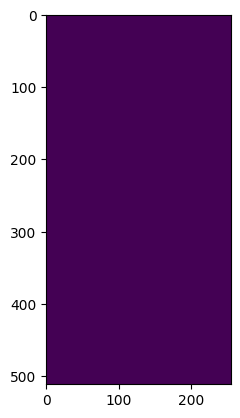

In [44]:
import matplotlib.pyplot as plt

plt.imshow(vx)